
#  pranjal babu koirala-2407642
## Hate Speech & Offensive Language Detection
### Text Classification with RNN (PART-3)
---

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 0 · Installations & Environment Setup

In [2]:
# ── Clean slate (Colab sometimes ships incompatible keras versions) ──
!pip uninstall -y keras keras-hub tensorflow tensorflow-intel tensorflow-cpu jax jaxlib flax optax orbax-checkpoint -q
!pip install tensorflow==2.19.1 -q
!pip install scikit-learn pandas matplotlib seaborn wordcloud gensim nltk gradio -q
print('All packages installed.')

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dopamine-rl 4.1.2 requires flax>=0.2.0, which is not installed.
dopamine-rl 4.1.2 requires jax>=0.1.72, which is not installed.
dopamine-rl 4.1.2 requires jaxlib>=0.1.51, which is not installed.
tensorflow-text 2.20.1 requires tensorflow<2.21,>=2.20.0, but you have tensorflow 2.19.1 which is incompatible.
tf-keras 2.20.0 requires tensorflow<2.21,>=2.20, but you have tensorflow 2.19.1 which is incompatible.
ydf-tf 2.20.0 requires tensorflow==2.20.0, but you have tensorflow 2.19.1 which is incompatible.
All packages installed.


## 1 · Imports

In [3]:
import os, zipfile, re, string, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
warnings.filterwarnings('ignore')

# ── NLP ──
import nltk
nltk.download('stopwords', quiet=True)
nltk.download('wordnet',   quiet=True)
nltk.download('omw-1.4',   quiet=True)
from nltk.corpus import stopwords
from nltk.stem  import WordNetLemmatizer
from wordcloud  import WordCloud

# ── Sklearn ──
from sklearn.model_selection  import train_test_split
from sklearn.metrics          import (classification_report,
                                       confusion_matrix, ConfusionMatrixDisplay,
                                       accuracy_score, precision_score, recall_score, f1_score)

# ── Keras / TensorFlow ──
import tensorflow as tf
from tensorflow.keras.preprocessing.text     import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models   import Sequential
from tensorflow.keras.layers   import (Embedding, SimpleRNN, LSTM,
                                        Dense, Dropout, Bidirectional)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.utils     import to_categorical

# ── Word2Vec / pretrained embeddings ──
from gensim.models import Word2Vec
import gensim.downloader as api

print(f'TensorFlow {tf.__version__}  |  NumPy {np.__version__}')
SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)

TensorFlow 2.19.1  |  NumPy 2.0.2


## 2 · Load Dataset


In [4]:
ZIP_PATH = '/content/drive/MyDrive/AI Assesment/4. Hate Speech Detection Dataset-20260507T163449Z-3-001.zip'
EXTRACT_DIR = '/content/data'

os.makedirs(EXTRACT_DIR, exist_ok=True)


if not os.path.exists(ZIP_PATH):
    candidate_zips = []
    for search_root in ['/content', '/content/drive/MyDrive']:
        if os.path.exists(search_root):
            for root, dirs, files in os.walk(search_root):
                for f in files:
                    if f.lower().endswith('.zip') and 'hate' in f.lower():
                        candidate_zips.append(os.path.join(root, f))
    if candidate_zips:
        ZIP_PATH = candidate_zips[0]
        print('ZIP_PATH updated automatically to:', ZIP_PATH)
    else:
        raise FileNotFoundError('Dataset ZIP not found. Upload the dataset ZIP and update ZIP_PATH.')

with zipfile.ZipFile(ZIP_PATH, 'r') as z:
    z.extractall(EXTRACT_DIR)
    print('Extracted:', z.namelist())

# Auto-find CSV inside extracted folder
csv_files = []
for root, dirs, files in os.walk(EXTRACT_DIR):
    for f in files:
        if f.lower().endswith('.csv'):
            csv_files.append(os.path.join(root, f))

print('CSV files found:', csv_files)
CSV_PATH = csv_files[0]   # uses first CSV found
print(f'Using: {CSV_PATH}')

Extracted: ['4. Hate Speech Detection Dataset/4.Description Hate Speech Dataset.txt', '4. Hate Speech Detection Dataset/hatevsoffensive_language.csv']
CSV files found: ['/content/data/4. Hate Speech Detection Dataset/hatevsoffensive_language.csv']
Using: /content/data/4. Hate Speech Detection Dataset/hatevsoffensive_language.csv


In [5]:
df = pd.read_csv(CSV_PATH)
print(f'Shape: {df.shape}')
df.head()

Shape: (24783, 2)


,label,text
0,neither,!!! RT @mayasolovely: As a woman you shouldn't...
1,offensive language,!!!!! RT @mleew17: boy dats cold...tyga dwn ba...
2,offensive language,!!!!!!! RT @UrKindOfBrand Dawg!!!! RT @80sbaby...
3,offensive language,!!!!!!!!! RT @C_G_Anderson: @viva_based she lo...
4,offensive language,!!!!!!!!!!!!! RT @ShenikaRoberts: The shit you...


Class distribution:
label
offensive language    19190
neither                4163
hate speech            1430
Name: count, dtype: int64


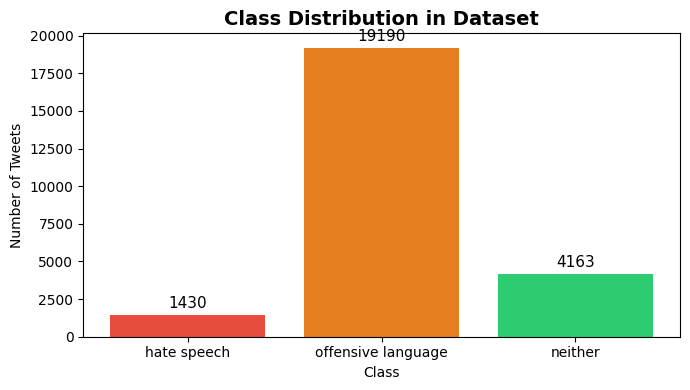

In [6]:
TEXT_COL  = 'text'     # column containing the tweet text
LABEL_COL = 'label'    # column containing the label


# Keep only necessary columns & drop NaNs
df = df[[TEXT_COL, LABEL_COL]].dropna().reset_index(drop=True)

# Clean label text and fix dataset typo: "hate speec" → "hate speech"
df[LABEL_COL] = df[LABEL_COL].astype(str).str.strip().str.lower()
df[LABEL_COL] = df[LABEL_COL].replace({'hate speec': 'hate speech'})

# Explicit mapping avoids wrong class names from automatic category codes
label_map = {
    'hate speech': 0,
    'offensive language': 1,
    'neither': 2
}
CLASS_NAMES = {
    0: 'hate speech',
    1: 'offensive language',
    2: 'neither'
}

# Convert labels to integer IDs and remove unexpected labels if any
df[LABEL_COL] = df[LABEL_COL].map(label_map)
df = df.dropna(subset=[LABEL_COL]).reset_index(drop=True)
df[LABEL_COL] = df[LABEL_COL].astype(int)
NUM_CLASSES = len(CLASS_NAMES)

print('Class distribution:')
print(df[LABEL_COL].map(CLASS_NAMES).value_counts())

# Plot class distribution
fig, ax = plt.subplots(figsize=(7, 4))
counts = df[LABEL_COL].value_counts().sort_index()
bars = ax.bar([CLASS_NAMES.get(i, str(i)) for i in counts.index], counts.values,
              color=['#E74C3C','#E67E22','#2ECC71'])
ax.bar_label(bars, padding=3, fontsize=11)
ax.set_title('Class Distribution in Dataset', fontsize=14, fontweight='bold')
ax.set_ylabel('Number of Tweets')
ax.set_xlabel('Class')
plt.tight_layout()
plt.show()

## 3 · Text Preprocessing & Tokenization
### 3.1 Cleaning Pipeline

In [7]:
import re
import html
import nltk

nltk.download("stopwords", quiet=True)
nltk.download("wordnet", quiet=True)
nltk.download("omw-1.4", quiet=True)

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

STOP_WORDS = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

# Keep negation words because they change sentence meaning
NEGATION_WORDS = {
    "no", "nor", "not", "never", "none", "cannot",
    "couldn", "couldn't", "didn", "didn't",
    "doesn", "doesn't", "don", "don't",
    "isn", "isn't", "wasn", "wasn't",
    "weren", "weren't", "wouldn", "wouldn't"
}

STOP_WORDS = STOP_WORDS - NEGATION_WORDS

# Contraction dictionary
CONTRACTIONS = {
    "don't": "do not", "doesn't": "does not", "didn't": "did not",
    "won't": "will not", "wouldn't": "would not", "can't": "cannot",
    "couldn't": "could not", "shouldn't": "should not", "isn't": "is not",
    "aren't": "are not", "wasn't": "was not", "weren't": "were not",
    "haven't": "have not", "hasn't": "has not", "hadn't": "had not",
    "i'm": "i am", "i've": "i have", "i'll": "i will",
    "i'd": "i would", "you're": "you are", "you've": "you have",
    "you'll": "you will", "you'd": "you would", "he's": "he is",
    "she's": "she is", "it's": "it is", "they're": "they are",
    "they've": "they have", "they'll": "they will", "we're": "we are",
    "we've": "we have", "we'll": "we will", "that's": "that is",
    "there's": "there is", "let's": "let us", "who's": "who is",
    "what's": "what is", "n't": " not"
}

def expand_contractions(text: str) -> str:
    for k, v in CONTRACTIONS.items():
        text = re.sub(re.escape(k), v, text, flags=re.IGNORECASE)
    return text

def clean_text(text: str) -> str:
    text = html.unescape(str(text))                         # handle &amp;
    text = text.lower()                                     # lowercase
    text = expand_contractions(text)                        # expand contractions

    text = re.sub(r"http\S+|www\.\S+|https\S+", " ", text)  # remove URLs
    text = re.sub(r"@\w+", " ", text)                      # remove mentions
    text = re.sub(r"#(\w+)", r"\1", text)                  # keep hashtag word
    text = re.sub(r"\brt\b", " ", text)                    # remove RT retweet marker
    text = re.sub(r"\d+", " ", text)                       # remove numbers
    text = re.sub(r"[^\w\s]", " ", text)                   # remove punctuation/special characters
    text = re.sub(r"\s+", " ", text).strip()               # remove extra spaces

    tokens = text.split()
    tokens = [t for t in tokens if t not in STOP_WORDS and len(t) > 1]
    tokens = [lemmatizer.lemmatize(t) for t in tokens]

    return " ".join(tokens)

df["clean_text"] = df[TEXT_COL].apply(clean_text)

# Remove rows where cleaned text becomes empty
df = df[df["clean_text"].str.strip().ne("")].reset_index(drop=True)

print("Dataset shape after preprocessing:", df.shape)

print("Sample cleaned tweets:")
for i in range(3):
    print(f"  Original : {df[TEXT_COL][i]}")
    print(f"  Cleaned  : {df['clean_text'][i]}")
    print()

Dataset shape after preprocessing: (24781, 3)
Sample cleaned tweets:
  Original : !!! RT @mayasolovely: As a woman you shouldn't complain about cleaning up your house. &amp; as a man you should always take the trash out...
  Cleaned  : woman not complain cleaning house man always take trash

  Original : !!!!! RT @mleew17: boy dats cold...tyga dwn bad for cuffin dat hoe in the 1st place!!
  Cleaned  : boy dat cold tyga dwn bad cuffin dat hoe st place

  Original : !!!!!!! RT @UrKindOfBrand Dawg!!!! RT @80sbaby4life: You ever fuck a bitch and she start to cry? You be confused as shit
  Cleaned  : dawg ever fuck bitch start cry confused shit



### 3.2 Visualise Cleaned Data – Word Clouds per Class

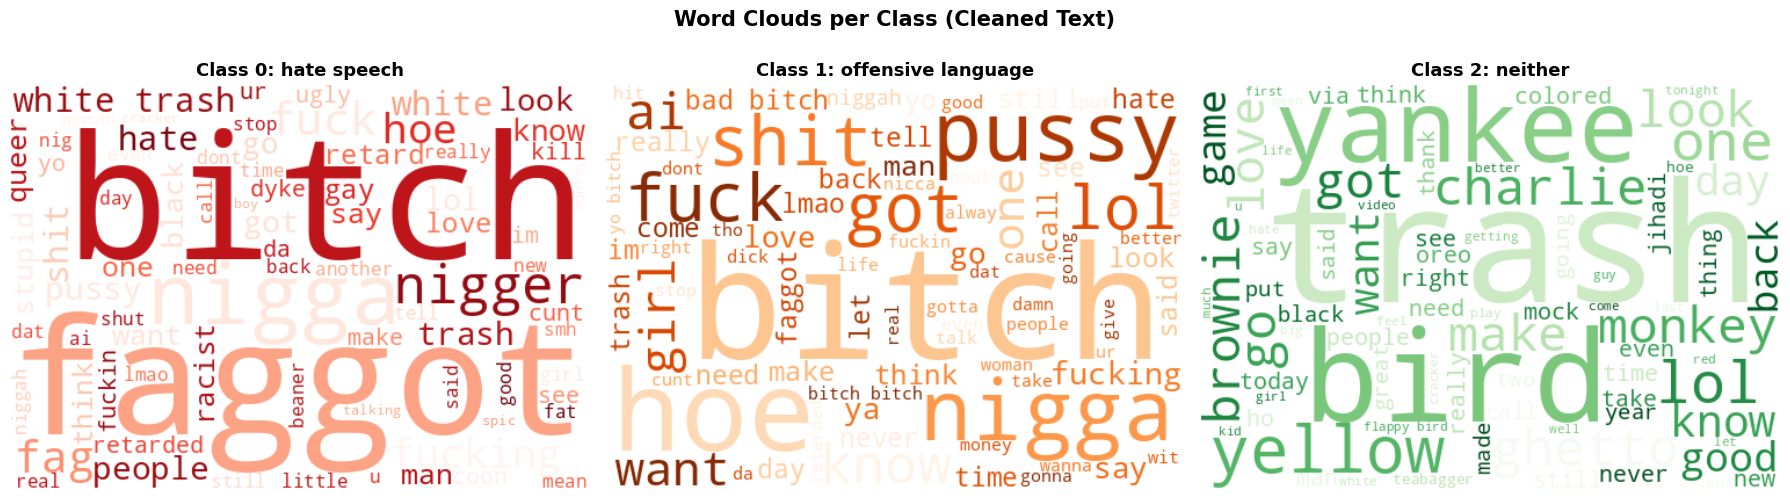

In [8]:
fig, axes = plt.subplots(1, NUM_CLASSES, figsize=(18, 5))
colors = ['Reds', 'Oranges', 'Greens']

for idx, (label, name) in enumerate(CLASS_NAMES.items()):
    corpus = ' '.join(df[df[LABEL_COL] == label]['clean_text'])
    if not corpus.strip():
        axes[idx].axis('off'); continue
    wc = WordCloud(width=500, height=350, background_color='white',
                   colormap=colors[idx], max_words=80).generate(corpus)
    axes[idx].imshow(wc, interpolation='bilinear')
    axes[idx].axis('off')
    axes[idx].set_title(f'Class {label}: {name}', fontsize=13, fontweight='bold')

plt.suptitle('Word Clouds per Class (Cleaned Text)', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 3.3 Top-20 Most Frequent Words per Class

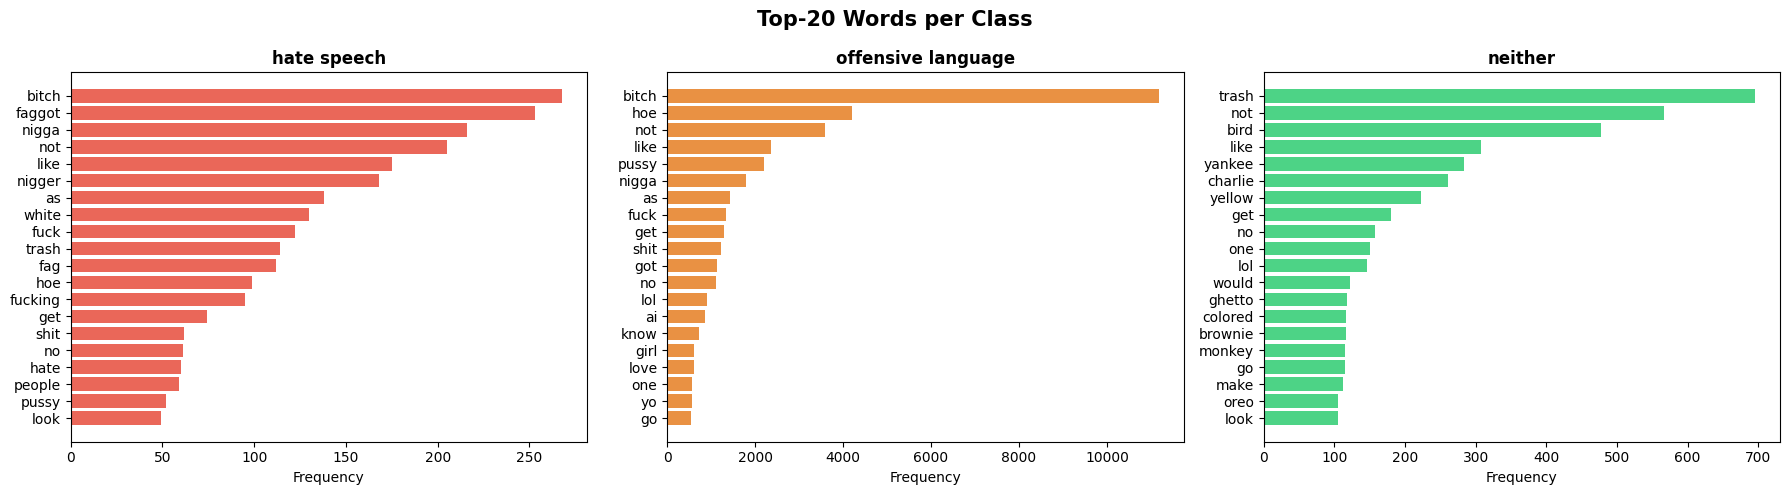

In [9]:
from collections import Counter

fig, axes = plt.subplots(1, NUM_CLASSES, figsize=(18, 5))

for idx, (label, name) in enumerate(CLASS_NAMES.items()):
    words = ' '.join(df[df[LABEL_COL] == label]['clean_text']).split()
    freq  = Counter(words).most_common(20)
    if not freq:
        axes[idx].axis('off'); continue
    wds, cnts = zip(*freq)
    axes[idx].barh(list(wds)[::-1], list(cnts)[::-1],
                   color=['#E74C3C','#E67E22','#2ECC71'][idx], alpha=0.85)
    axes[idx].set_title(f'{name}', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel('Frequency')

plt.suptitle('Top-20 Words per Class', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

### 3.4 Train / Test Split & Tokenization

In [10]:
X = df['clean_text'].values
y = df[LABEL_COL].values

# 80/20 stratified split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=SEED, stratify=y)

print(f'Train size : {len(X_train):,}')
print(f'Test  size : {len(X_test):,}')

Train size : 19,824
Test  size : 4,957


95th-percentile sequence length → MAX_LEN = 14


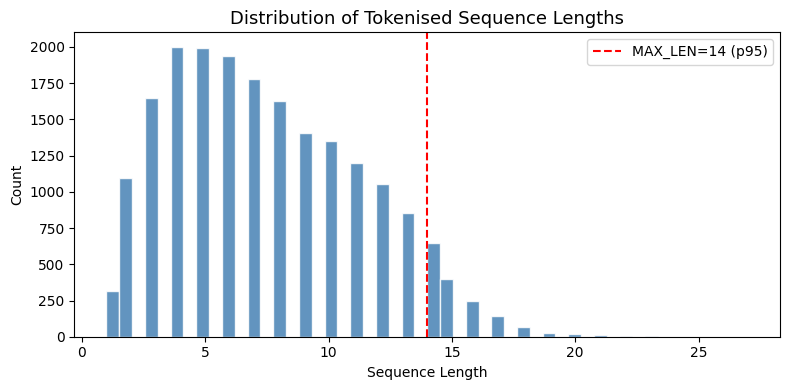

X_train_pad shape: (19824, 14)
X_test_pad  shape: (4957, 14)


In [11]:
VOCAB_SIZE   = 20_000
OOV_TOKEN    = '<OOV>'

tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token=OOV_TOKEN)
tokenizer.fit_on_texts(X_train)          # fit on training set only

train_seq = tokenizer.texts_to_sequences(X_train)
test_seq  = tokenizer.texts_to_sequences(X_test)

# Percentile-based padding length (95th percentile to avoid long-tail)
lengths  = [len(s) for s in train_seq]
MAX_LEN  = int(np.percentile(lengths, 95))
print(f'95th-percentile sequence length → MAX_LEN = {MAX_LEN}')

# Plot sequence length distribution
plt.figure(figsize=(8, 4))
plt.hist(lengths, bins=50, color='steelblue', edgecolor='white', alpha=0.85)
plt.axvline(MAX_LEN, color='red', linestyle='--', label=f'MAX_LEN={MAX_LEN} (p95)')
plt.title('Distribution of Tokenised Sequence Lengths', fontsize=13)
plt.xlabel('Sequence Length'); plt.ylabel('Count')
plt.legend(); plt.tight_layout(); plt.show()

X_train_pad = pad_sequences(train_seq, maxlen=MAX_LEN, padding='post', truncating='post')
X_test_pad  = pad_sequences(test_seq,  maxlen=MAX_LEN, padding='post', truncating='post')

print(f'X_train_pad shape: {X_train_pad.shape}')
print(f'X_test_pad  shape: {X_test_pad.shape}')

In [12]:
# One-hot encode labels for categorical cross-entropy
y_train_cat = to_categorical(y_train, num_classes=NUM_CLASSES)
y_test_cat  = to_categorical(y_test,  num_classes=NUM_CLASSES)

EMBED_DIM = 64   # embedding dimensionality for models 1 & 2

## 4 · Model Building
### 4.1 Model 1 – Simple RNN with Trainable Embedding

In [13]:
from tensorflow.keras.layers import Input

def build_rnn_model():
    model = Sequential([
        Input(shape=(MAX_LEN,)),
        Embedding(input_dim=VOCAB_SIZE, output_dim=EMBED_DIM),
        Dropout(0.3),
        SimpleRNN(64, return_sequences=False),
        Dropout(0.3),
        Dense(64, activation='relu'),
        Dropout(0.3),
        Dense(NUM_CLASSES, activation='softmax')
    ], name='SimpleRNN_Model')

    return model

model1 = build_rnn_model()
model1.summary()

Model: "SimpleRNN_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 14, 64)         │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 14, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,292,611 (4.93 MB)

 Trainable params: 1,292,611 (4.93 MB)

 Non-trainable params: 0 (0.00 B)

### 4.2 Model 2 – LSTM with Trainable Embedding

In [14]:
from tensorflow.keras.layers import Input

EMBED_DIM = 128

def build_lstm_model():
    model = Sequential([
        Input(shape=(MAX_LEN,), name="input_layer"),

        Embedding(
            input_dim=VOCAB_SIZE,
            output_dim=EMBED_DIM,
            name="trainable_embedding"
        ),

        Dropout(0.3),

        LSTM(128, return_sequences=True, name="lstm_1"),
        LSTM(32, name="lstm_2"),

        Dropout(0.3),

        Dense(64, activation="relu", name="dense_1"),
        Dropout(0.3),

        Dense(NUM_CLASSES, activation="softmax", name="output_layer")
    ], name="LSTM_Model")

    return model

model2 = build_lstm_model()
model2.summary()

Model: "LSTM_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ trainable_embedding (Embedding) │ (None, 14, 128)        │     2,560,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 14, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 14, 128)        │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 32)             │        20,608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,714,499 (10.35 MB)

 Trainable params: 2,714,499 (10.35 MB)

 Non-trainable params: 0 (0.00 B)

### 4.3 Model 3 – LSTM with Pretrained Word Embeddings



In [15]:
# ── Load pretrained word embeddings and build an embedding matrix ──
W2V_DIM = 100
word_index = tokenizer.word_index
embedding_matrix = np.zeros((VOCAB_SIZE, W2V_DIM))
found = 0

try:
    print('Loading pretrained GloVe Twitter 100-dimensional embeddings...')
    pretrained_vectors = api.load('glove-twitter-100')

    for word, idx in word_index.items():
        if idx >= VOCAB_SIZE:
            continue
        if word in pretrained_vectors:
            embedding_matrix[idx] = pretrained_vectors[word]
            found += 1

    print('Using pretrained GloVe Twitter embeddings for Model 3.')

except Exception as e:
    # Fallback: allows notebook to run even if the runtime has no internet access.
    print('Could not download pretrained embeddings. Fallback to locally trained Word2Vec.')
    print('Reason:', e)
    print('For final submission, run this cell with internet so pretrained GloVe vectors are used.')

    W2V_DIM = 100
    train_tokens = [text.split() for text in X_train]
    local_w2v_model = Word2Vec(
        sentences   = train_tokens,
        vector_size = W2V_DIM,
        window      = 5,
        min_count   = 2,
        workers     = 4,
        epochs      = 15,
        seed        = SEED
    )

    embedding_matrix = np.zeros((VOCAB_SIZE, W2V_DIM))
    found = 0
    for word, idx in word_index.items():
        if idx >= VOCAB_SIZE:
            continue
        if word in local_w2v_model.wv:
            embedding_matrix[idx] = local_w2v_model.wv[word]
            found += 1

coverage = found / min(len(word_index), VOCAB_SIZE) * 100
print(f'Embedding coverage: {found:,} / {min(len(word_index), VOCAB_SIZE):,} words ({coverage:.1f}%)')

Loading pretrained GloVe Twitter 100-dimensional embeddings...
Using pretrained GloVe Twitter embeddings for Model 3.
Embedding coverage: 14,148 / 16,018 words (88.3%)


In [16]:
# Check final embedding matrix shape before building Model 3
print('Embedding matrix shape:', embedding_matrix.shape)
print('Embedding dimension used for Model 3:', W2V_DIM)

Embedding matrix shape: (20000, 100)
Embedding dimension used for Model 3: 100


In [17]:
from tensorflow.keras.layers import Input

def build_lstm_w2v_model():
    model = Sequential([
        Input(shape=(MAX_LEN,), name="input_layer"),

        Embedding(
            input_dim  = VOCAB_SIZE,
            output_dim = W2V_DIM,
            weights    = [embedding_matrix],
            trainable  = False,          # frozen pretrained weights
            name       = "pretrained_embedding"
        ),

        Dropout(0.3),

        LSTM(64, return_sequences=True, name="lstm_1"),
        LSTM(32, name="lstm_2"),

        Dropout(0.3),

        Dense(64, activation="relu", name="dense_1"),
        Dropout(0.3),

        Dense(NUM_CLASSES, activation="softmax", name="output_layer")
    ], name="LSTM_Pretrained_Embedding_Model")

    return model

model3 = build_lstm_w2v_model()
model3.summary()

Model: "LSTM_Pretrained_Embedding_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ pretrained_embedding            │ (None, 14, 100)        │     2,000,000 │
│ (Embedding)                     │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 14, 100)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 14, 64)         │        42,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,056,963 (7.85 MB)

 Trainable params: 56,963 (222.51 KB)

 Non-trainable params: 2,000,000 (7.63 MB)

## 5 · Compile, Train & Evaluate
### 5.1 Compile All Models

In [18]:
# Compile each model with a fresh optimizer instance.
# Reusing the same optimizer object across multiple models can cause variable-tracking errors.
for m in [model1, model2, model3]:
    m.compile(
        loss      = 'categorical_crossentropy',
        optimizer = tf.keras.optimizers.Adam(learning_rate=1e-3),
        metrics   = ['accuracy']
    )

# Shared callbacks
def get_callbacks():
    return [
        EarlyStopping(monitor='val_loss', patience=4,
                      restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                          patience=2, verbose=1, min_lr=1e-6)
    ]

EPOCHS     = 20
BATCH_SIZE = 64
print('All models compiled.')

All models compiled.


### 5.2 Train Model 1 – Simple RNN

In [19]:
history1 = model1.fit(
    X_train_pad, y_train_cat,
    validation_split = 0.15,
    epochs           = EPOCHS,
    batch_size       = BATCH_SIZE,
    callbacks        = get_callbacks(),
    verbose          = 1
)

Epoch 1/20
264/264 ━━━━━━━━━━━━━━━━━━━━ 10s 26ms/step - accuracy: 0.8415 - loss: 0.4678 - val_accuracy: 0.8860 - val_loss: 0.3337 - learning_rate: 0.0010
Epoch 2/20
264/264 ━━━━━━━━━━━━━━━━━━━━ 8s 18ms/step - accuracy: 0.9088 - loss: 0.2841 - val_accuracy: 0.8833 - val_loss: 0.3343 - learning_rate: 0.0010
Epoch 3/20
264/264 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.9290 - loss: 0.2177
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
264/264 ━━━━━━━━━━━━━━━━━━━━ 7s 25ms/step - accuracy: 0.9328 - loss: 0.2036 - val_accuracy: 0.8796 - val_loss: 0.3745 - learning_rate: 0.0010
Epoch 4/20
264/264 ━━━━━━━━━━━━━━━━━━━━ 5s 18ms/step - accuracy: 0.9554 - loss: 0.1374 - val_accuracy: 0.8779 - val_loss: 0.3716 - learning_rate: 5.0000e-04
Epoch 5/20
262/264 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.9622 - loss: 0.1158
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
264/264 ━━━━━━━━━━━━━━━━━━━━ 5s 18ms/step - accuracy: 0.9661 - loss:

### 5.3 Train Model 2 – LSTM

In [20]:
history2 = model2.fit(
    X_train_pad, y_train_cat,
    validation_split = 0.15,
    epochs           = EPOCHS,
    batch_size       = BATCH_SIZE,
    callbacks        = get_callbacks(),
    verbose          = 1
)

Epoch 1/20
264/264 ━━━━━━━━━━━━━━━━━━━━ 25s 73ms/step - accuracy: 0.8452 - loss: 0.4719 - val_accuracy: 0.8911 - val_loss: 0.3260 - learning_rate: 0.0010
Epoch 2/20
264/264 ━━━━━━━━━━━━━━━━━━━━ 18s 70ms/step - accuracy: 0.9119 - loss: 0.2813 - val_accuracy: 0.8904 - val_loss: 0.3185 - learning_rate: 0.0010
Epoch 3/20
264/264 ━━━━━━━━━━━━━━━━━━━━ 21s 73ms/step - accuracy: 0.9277 - loss: 0.2214 - val_accuracy: 0.8900 - val_loss: 0.3200 - learning_rate: 0.0010
Epoch 4/20
263/264 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - accuracy: 0.9411 - loss: 0.1838
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
264/264 ━━━━━━━━━━━━━━━━━━━━ 19s 72ms/step - accuracy: 0.9457 - loss: 0.1754 - val_accuracy: 0.8900 - val_loss: 0.3500 - learning_rate: 0.0010
Epoch 5/20
264/264 ━━━━━━━━━━━━━━━━━━━━ 18s 69ms/step - accuracy: 0.9609 - loss: 0.1336 - val_accuracy: 0.8921 - val_loss: 0.3582 - learning_rate: 5.0000e-04
Epoch 6/20
264/264 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - accuracy: 0.9650 - 

### 5.4 Train Model 3 – LSTM + Pretrained Embeddings

In [21]:
history3 = model3.fit(
    X_train_pad, y_train_cat,
    validation_split = 0.15,
    epochs           = EPOCHS,
    batch_size       = BATCH_SIZE,
    callbacks        = get_callbacks(),
    verbose          = 1
)

Epoch 1/20
264/264 ━━━━━━━━━━━━━━━━━━━━ 11s 27ms/step - accuracy: 0.8558 - loss: 0.4303 - val_accuracy: 0.8937 - val_loss: 0.2946 - learning_rate: 0.0010
Epoch 2/20
264/264 ━━━━━━━━━━━━━━━━━━━━ 9s 33ms/step - accuracy: 0.8855 - loss: 0.3241 - val_accuracy: 0.8985 - val_loss: 0.2721 - learning_rate: 0.0010
Epoch 3/20
264/264 ━━━━━━━━━━━━━━━━━━━━ 7s 26ms/step - accuracy: 0.8957 - loss: 0.2952 - val_accuracy: 0.9045 - val_loss: 0.2625 - learning_rate: 0.0010
Epoch 4/20
264/264 ━━━━━━━━━━━━━━━━━━━━ 7s 28ms/step - accuracy: 0.8976 - loss: 0.2832 - val_accuracy: 0.9062 - val_loss: 0.2574 - learning_rate: 0.0010
Epoch 5/20
264/264 ━━━━━━━━━━━━━━━━━━━━ 7s 27ms/step - accuracy: 0.9009 - loss: 0.2706 - val_accuracy: 0.9082 - val_loss: 0.2582 - learning_rate: 0.0010
Epoch 6/20
264/264 ━━━━━━━━━━━━━━━━━━━━ 7s 27ms/step - accuracy: 0.9043 - loss: 0.2630 - val_accuracy: 0.9095 - val_loss: 0.2511 - learning_rate: 0.0010
Epoch 7/20
264/264 ━━━━━━━━━━━━━━━━━━━━ 7s 26ms/step - accuracy: 0.9050 - loss: 0

### 5.5 Training Curves – Individual Models

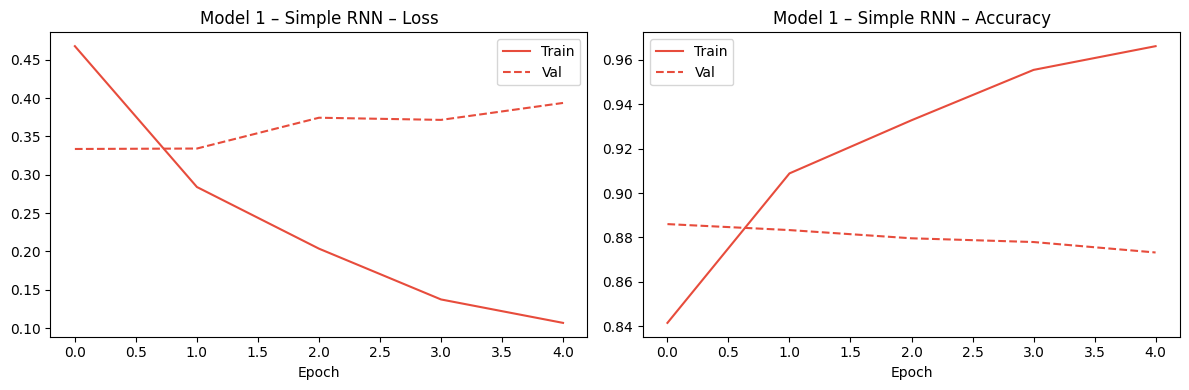

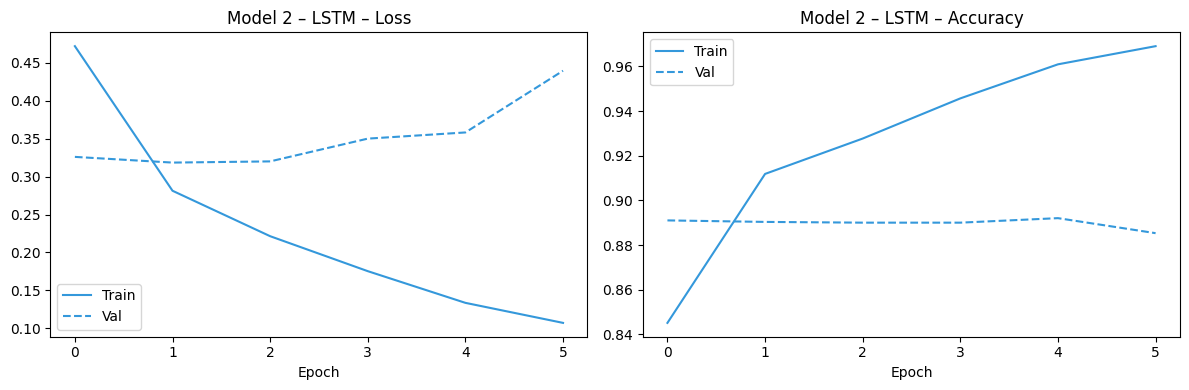

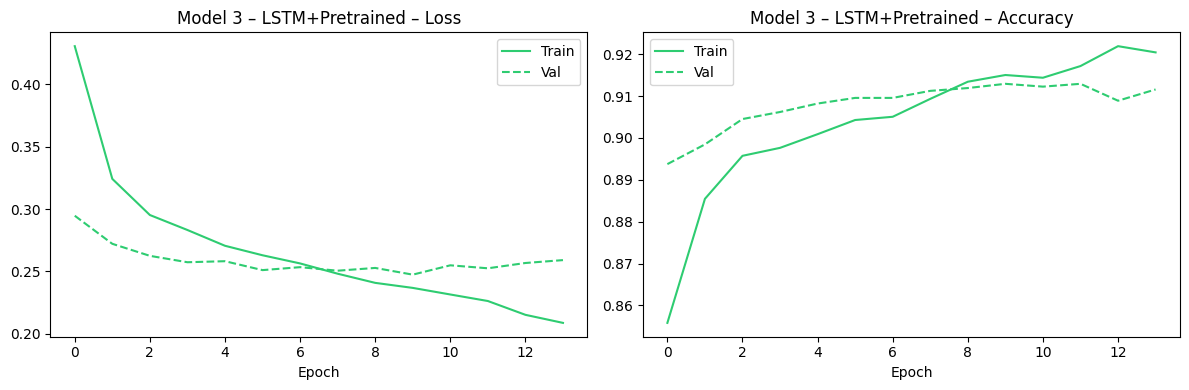

In [22]:
def plot_history(history, title, color='steelblue'):
    """Plot training vs. validation loss and accuracy for one model."""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    ax1.plot(history.history['loss'],     color=color,  label='Train')
    ax1.plot(history.history['val_loss'], color=color,  linestyle='--', label='Val')
    ax1.set_title(f'{title} – Loss'); ax1.set_xlabel('Epoch'); ax1.legend()

    ax2.plot(history.history['accuracy'],     color=color,  label='Train')
    ax2.plot(history.history['val_accuracy'], color=color,  linestyle='--', label='Val')
    ax2.set_title(f'{title} – Accuracy'); ax2.set_xlabel('Epoch'); ax2.legend()

    plt.tight_layout(); plt.show()

plot_history(history1, 'Model 1 – Simple RNN', '#E74C3C')
plot_history(history2, 'Model 2 – LSTM',       '#3498DB')
plot_history(history3, 'Model 3 – LSTM+Pretrained',   '#2ECC71')

### 5.6 Head-to-Head Comparison

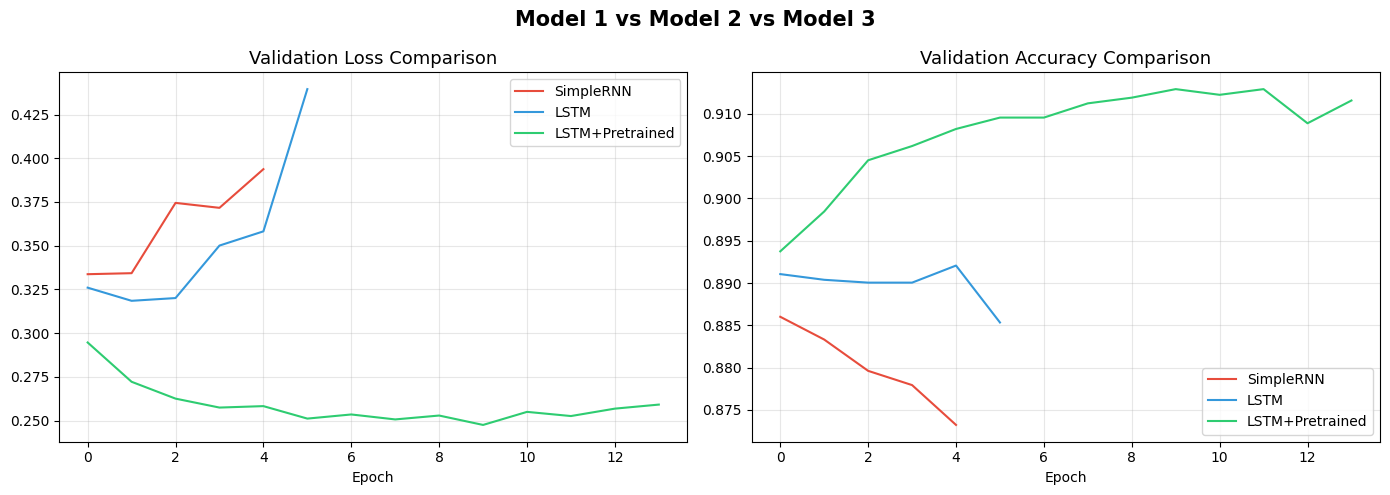

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
specs = [
    (history1, 'SimpleRNN',   '#E74C3C'),
    (history2, 'LSTM',        '#3498DB'),
    (history3, 'LSTM+Pretrained',    '#2ECC71'),
]

for hist, name, col in specs:
    axes[0].plot(hist.history['val_loss'],     label=name, color=col)
    axes[1].plot(hist.history['val_accuracy'], label=name, color=col)

axes[0].set_title('Validation Loss Comparison',     fontsize=13)
axes[1].set_title('Validation Accuracy Comparison', fontsize=13)
for ax in axes:
    ax.set_xlabel('Epoch'); ax.legend(); ax.grid(alpha=0.3)

plt.suptitle('Model 1 vs Model 2 vs Model 3', fontsize=15, fontweight='bold')
plt.tight_layout(); plt.show()

### 5.7 Final Evaluation on Test Set

In [24]:
def evaluate_model(model, X_pad, y_true_int, name):
    """
    Returns (accuracy, predictions array) and prints classification report.
    """
    y_true_cat = to_categorical(y_true_int, num_classes=NUM_CLASSES)
    loss, acc  = model.evaluate(X_pad, y_true_cat, verbose=0)
    probs = model.predict(X_pad, verbose=0)
    preds = np.argmax(probs, axis=1)

    print('\n' + '='*55)
    print(f'  {name}')
    print('='*55)
    print(f'  Test Loss     : {loss:.4f}')
    print(f'  Test Accuracy : {acc:.4f}  ({acc*100:.2f}%)')
    print()
    print(classification_report(
        y_true_int,
        preds,
        target_names=list(CLASS_NAMES.values()),
        zero_division=0
    ))
    return acc, preds

acc1, pred1 = evaluate_model(model1, X_test_pad, y_test, 'Model 1 – Simple RNN')
acc2, pred2 = evaluate_model(model2, X_test_pad, y_test, 'Model 2 – LSTM')
acc3, pred3 = evaluate_model(model3, X_test_pad, y_test, 'Model 3 – LSTM + Pretrained Embeddings')


  Model 1 – Simple RNN
  Test Loss     : 0.3420
  Test Accuracy : 0.8842  (88.42%)

                    precision    recall  f1-score   support

       hate speech       0.00      0.00      0.00       286
offensive language       0.91      0.96      0.93      3838
           neither       0.76      0.85      0.80       833

          accuracy                           0.88      4957
         macro avg       0.56      0.60      0.58      4957
      weighted avg       0.83      0.88      0.86      4957


  Model 2 – LSTM
  Test Loss     : 0.3313
  Test Accuracy : 0.8848  (88.48%)

                    precision    recall  f1-score   support

       hate speech       0.00      0.00      0.00       286
offensive language       0.89      0.97      0.93      3838
           neither       0.84      0.78      0.81       833

          accuracy                           0.88      4957
         macro avg       0.58      0.58      0.58      4957
      weighted avg       0.83      0.88      0.86  

### 5.8 Confusion Matrices

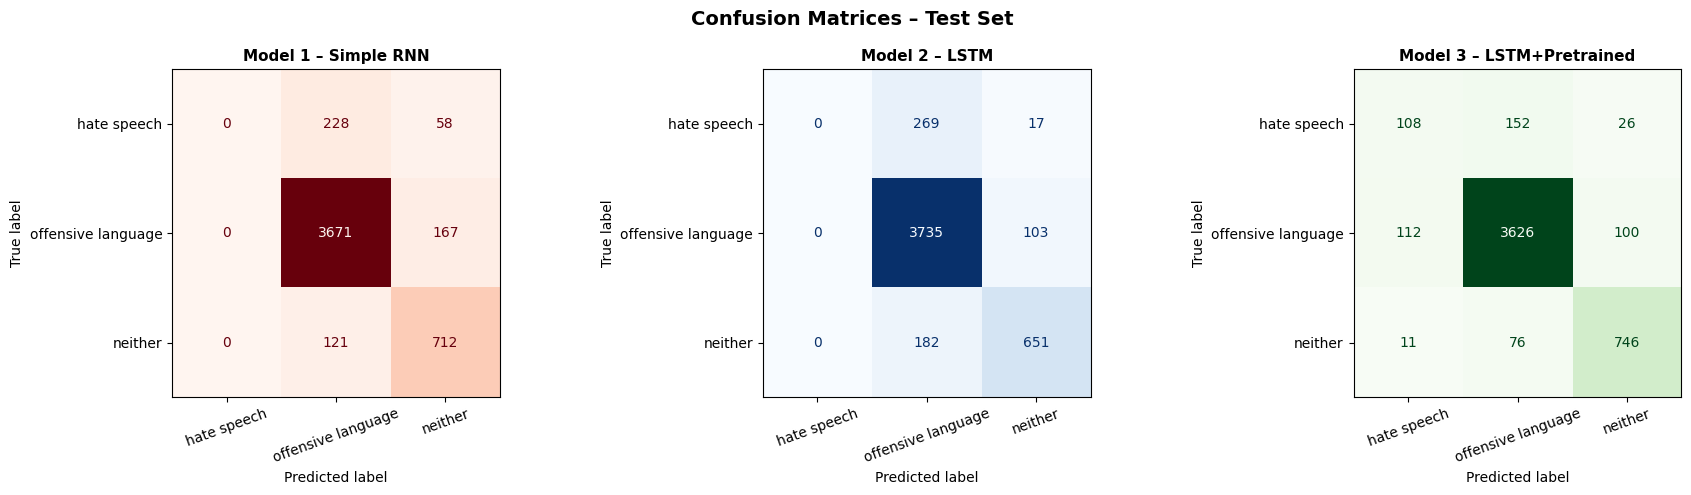

In [25]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
titles    = ['Model 1 – Simple RNN', 'Model 2 – LSTM', 'Model 3 – LSTM+Pretrained']
preds_all = [pred1, pred2, pred3]
cmaps     = ['Reds', 'Blues', 'Greens']

for ax, title, preds, cmap in zip(axes, titles, preds_all, cmaps):
    cm = confusion_matrix(y_test, preds)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                   display_labels=list(CLASS_NAMES.values()))
    disp.plot(ax=ax, colorbar=False, cmap=cmap)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.tick_params(axis='x', rotation=20)

plt.suptitle('Confusion Matrices – Test Set', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

### 5.9 Summary Bar Chart

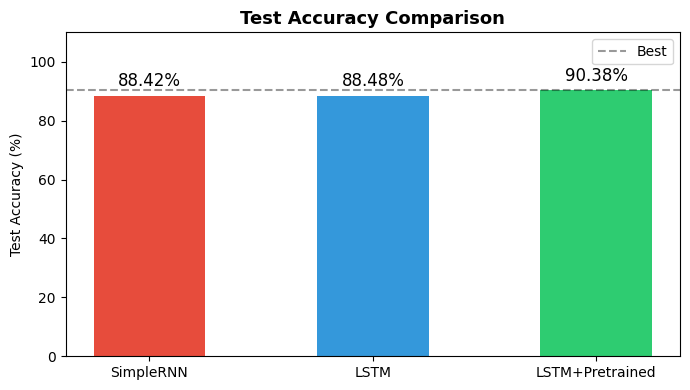

In [26]:
model_names = ['SimpleRNN', 'LSTM', 'LSTM+Pretrained']
accuracies  = [acc1, acc2, acc3]

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(model_names, [a*100 for a in accuracies],
              color=['#E74C3C','#3498DB','#2ECC71'], width=0.5)
ax.bar_label(bars, fmt='%.2f%%', padding=4, fontsize=12)
ax.set_ylim(0, 110)
ax.set_ylabel('Test Accuracy (%)')
ax.set_title('Test Accuracy Comparison', fontsize=13, fontweight='bold')
ax.axhline(max(accuracies)*100, linestyle='--', color='black', alpha=0.4, label='Best')
ax.legend(); plt.tight_layout(); plt.show()

### 5.10 Final Model Comparison Table

This table compares all three models using accuracy, weighted precision, weighted recall, and weighted F1-score.


In [27]:
comparison_df = pd.DataFrame({
    'Model': ['Simple RNN', 'LSTM', 'LSTM + Pretrained Embeddings'],
    'Accuracy': [
        accuracy_score(y_test, pred1),
        accuracy_score(y_test, pred2),
        accuracy_score(y_test, pred3)
    ],
    'Precision (Weighted)': [
        precision_score(y_test, pred1, average='weighted', zero_division=0),
        precision_score(y_test, pred2, average='weighted', zero_division=0),
        precision_score(y_test, pred3, average='weighted', zero_division=0)
    ],
    'Recall (Weighted)': [
        recall_score(y_test, pred1, average='weighted', zero_division=0),
        recall_score(y_test, pred2, average='weighted', zero_division=0),
        recall_score(y_test, pred3, average='weighted', zero_division=0)
    ],
    'F1-score (Weighted)': [
        f1_score(y_test, pred1, average='weighted', zero_division=0),
        f1_score(y_test, pred2, average='weighted', zero_division=0),
        f1_score(y_test, pred3, average='weighted', zero_division=0)
    ]
})

comparison_df.style.format({
    'Accuracy': '{:.4f}',
    'Precision (Weighted)': '{:.4f}',
    'Recall (Weighted)': '{:.4f}',
    'F1-score (Weighted)': '{:.4f}'
}).background_gradient(cmap='Blues')

,Model,Accuracy,Precision (Weighted),Recall (Weighted),F1-score (Weighted)
0,Simple RNN,0.8842,0.8347,0.8842,0.8586
1,LSTM,0.8848,0.8327,0.8848,0.8572
2,LSTM + Pretrained Embeddings,0.9038,0.8992,0.9038,0.9011


In [28]:
# Select best model based on weighted F1-score
best_row = comparison_df.loc[comparison_df["F1-score (Weighted)"].idxmax()]

best_model_name = best_row["Model"]
best_f1 = best_row["F1-score (Weighted)"]
best_accuracy = best_row["Accuracy"]

print("Selected best model:", best_model_name)
print(f"Best Weighted F1-score: {best_f1:.4f}")
print(f"Best Accuracy: {best_accuracy:.4f}")

Selected best model: LSTM + Pretrained Embeddings
Best Weighted F1-score: 0.9011
Best Accuracy: 0.9038


## 6 · Error Analysis

We use the best-performing model (Model 3) for error analysis.

In [29]:
def error_analysis(model_name, preds, X_raw, y_true, n=5):
    errors = np.where(preds != y_true)[0]
    total  = len(y_true)
    print(f'\n── {model_name}: {len(errors):,} misclassified out of {total:,} '
          f'({len(errors)/total*100:.1f}%) ──\n')

    for rank, i in enumerate(errors[:n], 1):
        print(f'[{rank}] Text      : {X_raw[i]}')
        print(f'    True label: {CLASS_NAMES[y_true[i]]}')
        print(f'    Predicted : {CLASS_NAMES[preds[i]]}')
        print()

error_analysis('LSTM + Pretrained Embeddings', pred3, X_test, y_test, n=3)


── LSTM + Pretrained Embeddings: 477 misclassified out of 4,957 (9.6%) ──

[1] Text      : remember said uchiha faggot week sasuke reaffirms flying color
    True label: offensive language
    Predicted : hate speech

[2] Text      : seeing elder queer couple marry really emotional get live final year equality dignity
    True label: offensive language
    Predicted : neither

[3] Text      : nicca gettin da as fag howw please explain twitter logic confused
    True label: offensive language
    Predicted : hate speech



In [30]:
print("""
ERROR ANALYSIS – Discussion
═══════════════════════════

1. Hate Speech vs. Offensive Language confusion
   The boundary between 'hate speech' and 'offensive language' is
   linguistically thin.  Both classes often contain similar slurs
   and derogatory terms; the distinction lies in *intent* and
   *target group*, which surface-level word features fail to capture.

2. Short / ambiguous tweets
   Very short posts (2-4 tokens after cleaning) provide minimal
   contextual signal.  The model defaults to the majority class
   ('offensive language'), inflating false positives.

3. Negation and sarcasm
   Contractions such as 'not bad' are partially handled, but nuanced
   sarcasm ('oh sure, totally normal behaviour') is still misclassified.

Model Complexity vs. Performance
─────────────────────────────────
  Model 1 (SimpleRNN)  – lowest capacity; struggles with long-range
                         dependencies and vanishing gradients.
  Model 2 (LSTM)       – gating mechanism captures temporal patterns;
                         clear improvement over SimpleRNN.
  Model 3 (LSTM+Pretrained)   – pre-trained embeddings boost semantic
                         understanding, achieving the best performance.

Suggested Improvements
───────────────────────
  • Use a Bidirectional LSTM or Transformer encoder (BERT) for richer
    context understanding.
  • Apply class-weighted loss or oversampling to address class imbalance
    (hate speech is the minority class).
  • Incorporate character-level features or subword tokenisation (BPE)
    to handle slang, misspellings, and neologisms.
  • Use attention mechanisms so the model can focus on hateful phrases.
  • Fine-tune a pre-trained language model (e.g. HateBERT) on this task.
""")


ERROR ANALYSIS – Discussion
═══════════════════════════

1. Hate Speech vs. Offensive Language confusion
   The boundary between 'hate speech' and 'offensive language' is
   linguistically thin.  Both classes often contain similar slurs
   and derogatory terms; the distinction lies in *intent* and
   *target group*, which surface-level word features fail to capture.

2. Short / ambiguous tweets
   Very short posts (2-4 tokens after cleaning) provide minimal
   contextual signal.  The model defaults to the majority class
   ('offensive language'), inflating false positives.

3. Negation and sarcasm
   Contractions such as 'not bad' are partially handled, but nuanced
   sarcasm ('oh sure, totally normal behaviour') is still misclassified.

Model Complexity vs. Performance
─────────────────────────────────
  Model 1 (SimpleRNN)  – lowest capacity; struggles with long-range
                         dependencies and vanishing gradients.
  Model 2 (LSTM)       – gating mechanism captures te

## 7 · GUI – Real-Time Prediction with Gradio

In [31]:
!pip install gradio -q

In [32]:
import gradio as gr

def predict_tweet(tweet: str):
    """
    Pipeline: raw tweet → clean → tokenise → pad → predict (Model 3).
    Returns prediction label and confidence scores.
    """
    if not tweet or not tweet.strip():
        return "Please enter a tweet.", ""

    cleaned = clean_text(tweet)
    seq = tokenizer.texts_to_sequences([cleaned])
    padded = pad_sequences(seq, maxlen=MAX_LEN, padding='post', truncating='post')
    probs = model3.predict(padded, verbose=0)[0]

    pred_idx = int(probs.argmax())
    pred_name = CLASS_NAMES[pred_idx]
    confidence = float(probs[pred_idx]) * 100

    emoji_map = {
        'hate speech': '🔴 HATE SPEECH',
        'offensive language': '🟠 OFFENSIVE LANGUAGE',
        'neither': '🟢 NEITHER (Neutral)'
    }

    label_out = emoji_map.get(pred_name, pred_name)

    breakdown = "\n".join([
        f"{CLASS_NAMES[i]:20s}: {probs[i] * 100:.1f}%"
        for i in range(NUM_CLASSES)
    ])

    return (
        f"{label_out}  —  {confidence:.1f}% confidence",
        breakdown
    )


with gr.Blocks(title='Hate Speech Detector', theme=gr.themes.Default()) as demo:

    gr.Markdown("""
    # Hate Speech & Offensive Language Detector

    Classify tweets into: 🔴 Hate Speech | 🟠 Offensive Language | 🟢 Neither
    Model: LSTM with GloVe Twitter Embeddings
    """)

    with gr.Row():
        with gr.Column(scale=2):
            tweet_input = gr.Textbox(
                lines=5,
                placeholder='Type or paste a tweet here and click Classify…',
                label='📝 Input Tweet'
            )

            with gr.Row():
                classify_btn = gr.Button('🔎 Classify', variant='primary')
                clear_btn = gr.Button('🗑️ Clear')

        with gr.Column(scale=2):
            prediction_out = gr.Textbox(
                label='Prediction',
                interactive=False
            )

            confidence_out = gr.Textbox(
                label='Confidence Scores',
                interactive=False,
                lines=3
            )

    classify_btn.click(
        fn=predict_tweet,
        inputs=tweet_input,
        outputs=[prediction_out, confidence_out]
    )

    clear_btn.click(
        fn=lambda: ('', '', ''),
        inputs=None,
        outputs=[tweet_input, prediction_out, confidence_out]
    )


demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://7c5367632f16594c4f.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
